In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Uploading the Excel File

Since the file `BlinkIT Grocery Data.xlsx` was not found, you need to upload it to your Colab session. The following cell will provide a button to browse and upload your file. Once uploaded, it will be placed in the `/content/` directory, allowing the `pd.read_excel()` function to find it.

In [10]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving BlinkIT Grocery Data.xlsx to BlinkIT Grocery Data.xlsx
User uploaded file "BlinkIT Grocery Data.xlsx" with length 595004 bytes


In [11]:
df = pd.read_excel('/content/BlinkIT Grocery Data.xlsx', engine='openpyxl')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [13]:
print(df.describe())

       Outlet Establishment Year  Item Visibility  Item Weight        Sales  \
count                8523.000000      8523.000000  7060.000000  8523.000000   
mean                 2016.450546         0.066132    12.857645   140.992783   
std                     3.189396         0.051598     4.643456    62.275067   
min                  2011.000000         0.000000     4.555000    31.290000   
25%                  2014.000000         0.026989     8.773750    93.826500   
50%                  2016.000000         0.053931    12.600000   143.012800   
75%                  2018.000000         0.094585    16.850000   185.643700   
max                  2022.000000         0.328391    21.350000   266.888400   

            Rating  
count  8523.000000  
mean      3.965857  
std       0.605651  
min       1.000000  
25%       4.000000  
50%       4.000000  
75%       4.200000  
max       5.000000  


In [14]:
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2014,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [15]:
df.shape

(8523, 12)

In [16]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [39]:
df.dtypes

,0
Item Fat Content,object
Item Identifier,object
Item Type,object
Outlet Establishment Year,int64
Outlet Identifier,object
Outlet Location Type,object
Outlet Size,object
Outlet Type,object
Item Visibility,float64
Item Weight,float64


In [18]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [19]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF': 'Low Fat', 'Regular': 'Regular', 'reg': 'Regular', 'low fat': 'Low Fat'})

In [20]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


In [23]:
#total_sales
total_sales = df['Sales'].sum()
print(f"Total sales: ${total_sales:.0f}")

#average sales
average_sales = df['Sales'].mean()
print(f"Average sales: ${average_sales:.0f}")

#No of items sold
no_of_items_sold = df['Sales'].count()
print(f"No of items sold: {no_of_items_sold:,.0f}")

# average rating
avg_rating = df['Rating'].mean()
print(f"Average rating: {avg_rating:.0f}")


Total sales: $1201681
Average sales: $141
No of items sold: 8,523
Average rating: 4


**Numpy**

In [37]:

sales = df["Sales"].to_numpy()

print("Mean:", np.mean(sales))
print("Median:", np.median(sales))
print("Max:", np.max(sales))
print("Min:", np.min(sales))
print("Std Dev:", np.std(sales))

Mean: 140.99278338613163
Median: 143.0128
Max: 266.8884
Min: 31.29
Std Dev: 62.27141334999408


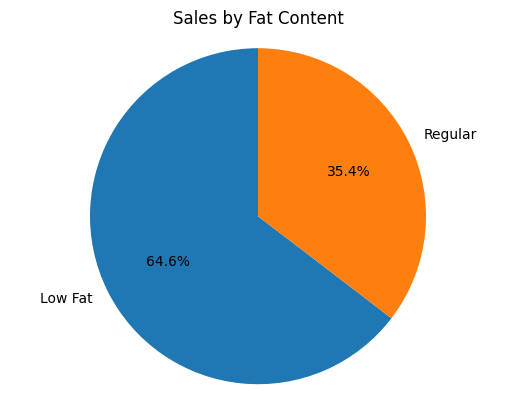

In [26]:
Sales_by_fat_content = df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(Sales_by_fat_content, labels=Sales_by_fat_content.index, autopct='%1.1f%%',startangle = 90)
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

**Total sales by outlet type** **bold text**

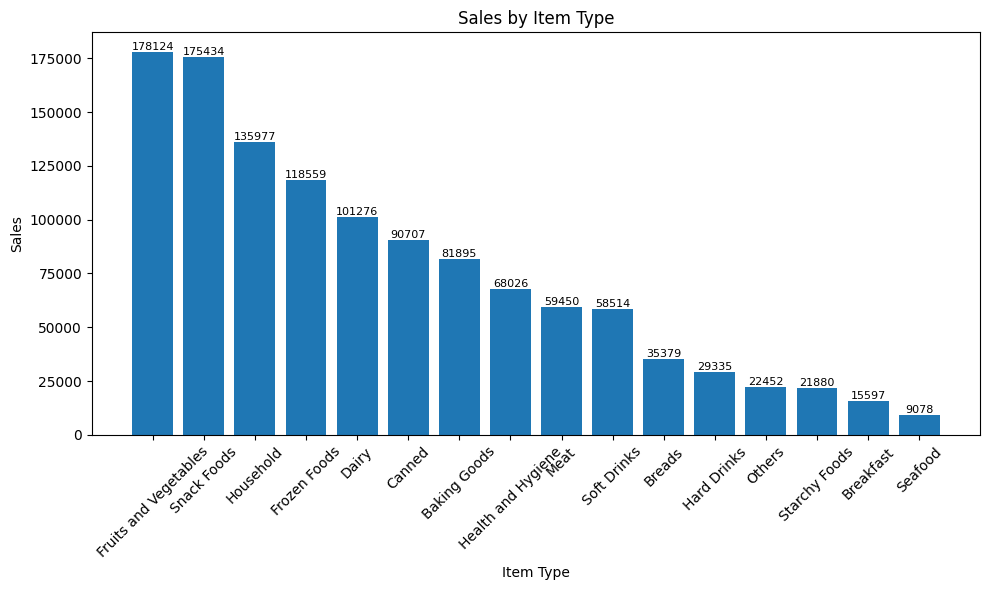

In [29]:
Sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.bar(Sales_by_type.index, Sales_by_type.values)
plt.xticks(rotation=45)


plt.title('Sales by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Sales')

for bar in bars:
  plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.0f}',
           ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()



**Fat content by outlet for total sale**


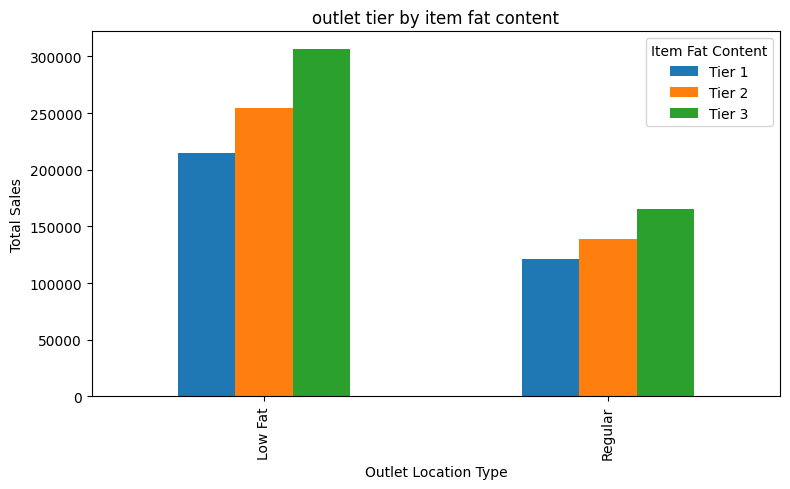

In [34]:
grouped = df.groupby(['Item Fat Content', 'Outlet Location Type'])['Sales'].sum().unstack()
# The following line was trying to select columns that don't exist.
# The 'grouped' DataFrame is already in the correct format for plotting.
# grouped = grouped[['Regular','Low Fat']]

ax = grouped.plot(kind = 'bar',figsize=(8,5),title = 'outlet tier by item fat content')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()

### Reading a CSV file with pandas

If you have a CSV file, you can use `pd.read_csv()` to load it into a DataFrame. Here's an example:

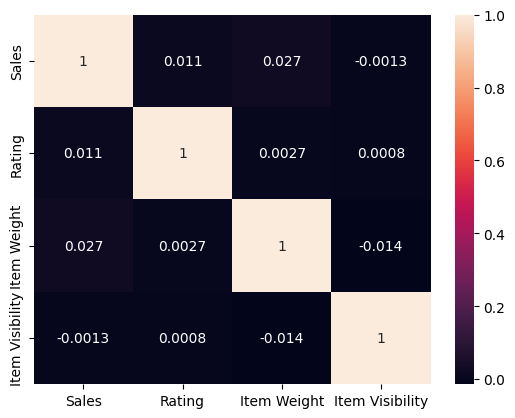

In [35]:
import seaborn as sns

sns.heatmap(
    df[["Sales","Rating","Item Weight","Item Visibility"]].corr(),
    annot=True
)
plt.show()

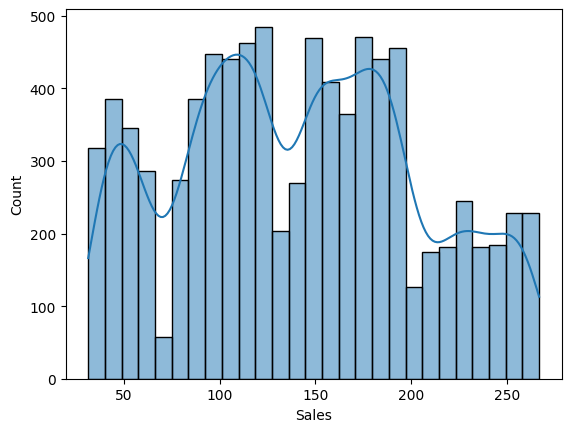

In [36]:
sns.histplot(df["Sales"], kde=True)
plt.show()